In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Part 1 – Get to Know the Dataset
1. Load the CSV file into pandas. What are the dimensions of the dataset?


*   Display the first 5 rows.

*   Report the number of rows and columns.



In [29]:
# Load the CSV file into pandas
import pandas as pd
slcm = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Assignment 1/SLCM_Basic_Needs_Class_Practice.csv")

In [30]:
#Display the first 5 rows
slcm.head()

,Housing_Status,Monthly_Housing_Cost,Moves_Last_3_Years,Utility_Disconnection_Risk,Monthly_LGE_Bill,Monthly_Water_Bill,Eviction_Record,Transportation_Need_Score,Has_Car,Bus_Use
0,Renter - past due rent,1200.0,0,Yes,225.0,200.0,No,1,Yes,Never
1,Renter - past due rent,0.0,1,No,217.0,144.0,No,2,Yes,Never
2,Staying with friends or family,800.0,4,No,100.0,100.0,No,5,Yes,Sometimes
3,Homeless,0.0,2,No,0.0,0.0,Yes,0,Yes,Never
4,Homeless,0.0,3,No,0.0,0.0,Yes,3,Yes,Rarely


In [31]:
#Report the number of rows and columns.
slcm.shape

(166, 10)

2. What variables are available?



*   Print the column names.
*   For each variable, write one short sentence describing what you think it represents.




In [32]:
#Print column names
slcm.columns

Index(['Housing_Status', 'Monthly_Housing_Cost', 'Moves_Last_3_Years',
       'Utility_Disconnection_Risk', 'Monthly_LGE_Bill', 'Monthly_Water_Bill',
       'Eviction_Record', 'Transportation_Need_Score', 'Has_Car', 'Bus_Use'],
      dtype='object')

Housing_Status: Describes the person’s current housing situation.
Monthly_Housing_Cost: Represents how much the person pays for housing each month.
Moves_Last_3_Years: Represents how many times the person has moved in the last three years.
Utility_Disconnection_Risk: Indicates whether the person is at risk of having their utilities disconnected.
Monthly_LGE_Bill: Represents the person’s monthly LG&E utility bill.
Monthly_Water_Bill: Represents the person’s monthly water bill.
Eviction_Record: Indicates whether the person has an eviction record.
Transportation_Need_Score: Represents the person’s level of transportation need.
Has_Car: Indicates whether the person has access to a car.
Bus_Use: Describes how often the person uses the bus.

3. What data types did pandas assign to the variables?



*   Use info() and/or dtypes.
*   Which columns are numeric?
*   Which columns are categorical/object?
*   Does any column have a data type that makes you want to inspect it more closely? Explain.





In [33]:
slcm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Housing_Status              166 non-null    object 
 1   Monthly_Housing_Cost        166 non-null    float64
 2   Moves_Last_3_Years          166 non-null    object 
 3   Utility_Disconnection_Risk  166 non-null    object 
 4   Monthly_LGE_Bill            166 non-null    float64
 5   Monthly_Water_Bill          166 non-null    float64
 6   Eviction_Record             166 non-null    object 
 7   Transportation_Need_Score   166 non-null    int64  
 8   Has_Car                     166 non-null    object 
 9   Bus_Use                     166 non-null    object 
dtypes: float64(3), int64(1), object(6)
memory usage: 13.1+ KB


Numeric variables: Monthly_Housing_Cost, Monthly_LGE_Bill, Monthly_Water_Bill, and Transportation_Need_Score.
Categorical/object variables: Housing_Status, Moves_Last_3_Years, Utility_Disconnection_Risk, Eviction_Record, Has_Car, and Bus_Use.
Moves_Last_3_Years is stored as an object instead of a numeric variable, so I would inspect it more closely to see what kinds of values it contains and whether it needs to be cleaned or recoded before numerical analysis.

Part 2 – Investigate Data Quality
5. Are there missing values or duplicate rows?


*   Calculate the number of missing values in every column.
*   Check for duplicate rows
*   Report what you find





In [34]:
# Calculate the number of missing values in every column
slcm.isnull().sum()


,0
Housing_Status,0
Monthly_Housing_Cost,0
Moves_Last_3_Years,0
Utility_Disconnection_Risk,0
Monthly_LGE_Bill,0
Monthly_Water_Bill,0
Eviction_Record,0
Transportation_Need_Score,0
Has_Car,0
Bus_Use,0


In [35]:
#Check duplicates
slcm.duplicated().sum()

np.int64(1)

In [36]:
slcm[slcm.duplicated(keep=False)]

,Housing_Status,Monthly_Housing_Cost,Moves_Last_3_Years,Utility_Disconnection_Risk,Monthly_LGE_Bill,Monthly_Water_Bill,Eviction_Record,Transportation_Need_Score,Has_Car,Bus_Use
3,Homeless,0.0,2,No,0.0,0.0,Yes,0,Yes,Never
42,Homeless,0.0,2,No,0.0,0.0,Yes,0,Yes,Never


There are no missing values in the dataset. Pandas identifies one duplicate row because two records have identical values across all variables. However, since there is no unique participant ID, I cannot confirm whether this is an accidental duplicate or two different people with the same responses, so it should be investigated before removing it.

6. What do the numeric variables look like?

Use describe() for Monthly_Housing_Cost, Monthly_LGE_Bill, Monthly_Water_Bill, and Transportation_Need_Score.
For each variable, identify its minimum, maximum, and typical values.
Which values look unusual or deserve a closer look?

In [37]:
slcm.describe()

,Monthly_Housing_Cost,Monthly_LGE_Bill,Monthly_Water_Bill,Transportation_Need_Score
count,166.000000,166.000000,166.000000,166.000000
mean,625.209181,420.003320,42.167815,2.433735
std,560.109409,3587.214867,99.524462,1.796918
min,0.000000,0.000000,0.000000,0.000000
25%,0.010000,0.010000,0.000000,1.000000
50%,550.000000,120.000000,0.010000,3.000000
75%,1100.000000,200.000000,60.000000,4.000000
max,2000.000000,46247.000000,1000.000000,5.000000


Monthly_Housing_Cost ranges from $0 to $2,000, with a median of $550, so a typical housing cost is around $550 per month.
Monthly_LGE_Bill ranges from $0 to $46,247, while most values are much lower, so the maximum value of $46,247 looks extremely unusual and should be investigated. Monthly_Water_Bill ranges from $0 to $1,000, and the $1,000 maximum also appears unusually high compared with the typical values. Transportation_Need_Score ranges from 0 to 5, with a median of 3, and its values appear reasonable for a score on this scale. The zero values in the housing and utility variables also deserve a closer look because they may represent a real situation rather than missing or incorrect data.

7. Investigate zero values.

• Count how many records have Monthly_Housing_Cost = 0.

• Count how many records have Monthly_LGE_Bill = 0 and Monthly_Water_Bill = 0.

• Look at Housing_Status for records with Monthly_Housing_Cost = 0.

• Does a zero always appear to mean “bad data”? Explain what else zero could reasonably mean in this
dataset.


In [38]:
#• Count how many records have Monthly_Housing_Cost = 0
slcm[slcm['Monthly_Housing_Cost'] == 0].shape[0]

31

In [39]:
#Count how many records have Monthly_LGE_Bill = 0 and Monthly_Water_Bill = 0
slcm[(slcm['Monthly_LGE_Bill'] == 0) & (slcm['Monthly_Water_Bill'] == 0)].shape[0]


36

In [40]:
# Look at Housing_Status for records with Monthly_Housing_Cost = 0
slcm[slcm['Monthly_Housing_Cost'] == 0]['Housing_Status']


,Housing_Status
1,Renter - past due rent
3,Homeless
4,Homeless
6,Renter - no rent past due
8,Homeless
12,Renter - no rent past due
16,Renter - no rent past due
22,Renter - no rent past due
27,Staying with friends or family
32,Renter - no rent past due


A zero value does not always mean bad data. For example, someone who is homeless or staying with friends or family may reasonably have no monthly housing cost. A person may also have a $0 utility bill if utilities are included in their rent or paid by someone else. However, some zero values, such as renters reporting no housing cost, may deserve further investigation to understand what the zero represents.

8. Investigate Moves_Last_3_Years.

• Display all unique values and their counts.

• Can the values be used directly as numbers?

• If not, explain how you would clean or recode this variable for future analysis.

In [41]:
# Display all unique values and their counts.
slcm['Moves_Last_3_Years'].value_counts()

,count
Moves_Last_3_Years,
1,43
2,40
0,34
3,20
More than 5,15
4,10
5,4


9. Make a cleaned working copy of the dataset.

• Create a new DataFrame for your cleaned data.

• Make at least TWO reasonable cleaning/preparation changes based on what you found above.

• For each change, explain exactly what you changed and why.

• Run checks afterward to verify that the changes worked.


In [42]:
# Create a new DataFrame for the cleaned data
slcm_clean = slcm.copy()

Visualize outliers

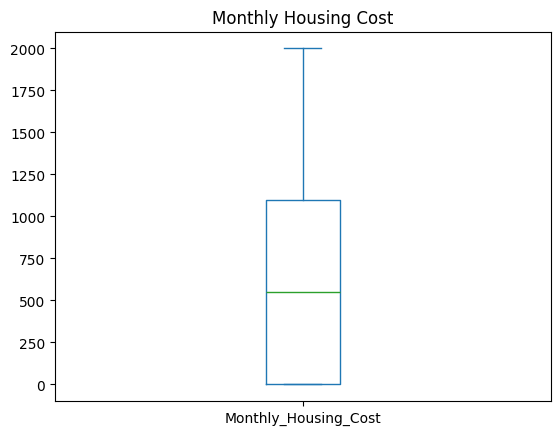

In [43]:
import matplotlib.pyplot as plt
%matplotlib inline

slcm_clean['Monthly_Housing_Cost'].plot(kind='box')
plt.title('Monthly Housing Cost')
plt.show()

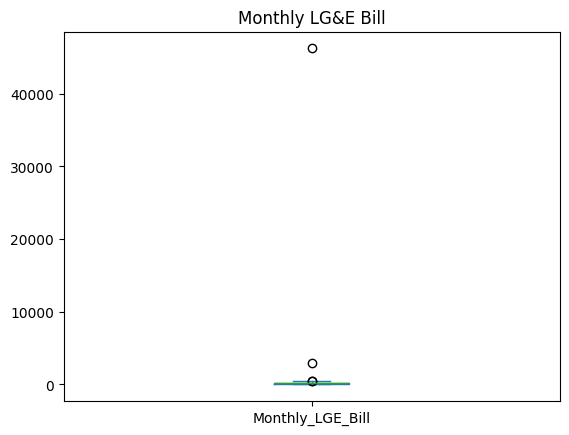

In [44]:

slcm_clean['Monthly_LGE_Bill'].plot(kind='box')
plt.title('Monthly LG&E Bill')
plt.show()


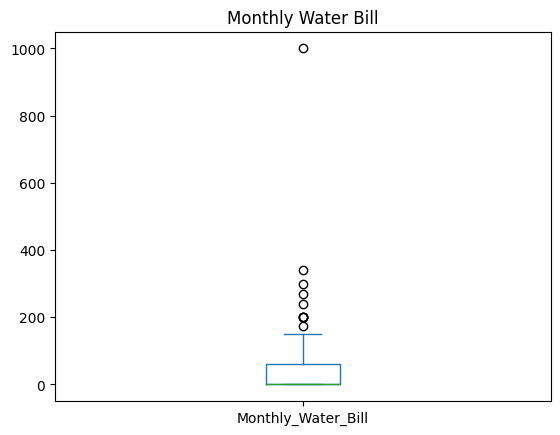

In [45]:

slcm_clean['Monthly_Water_Bill'].plot(kind='box')
plt.title('Monthly Water Bill')
plt.show()


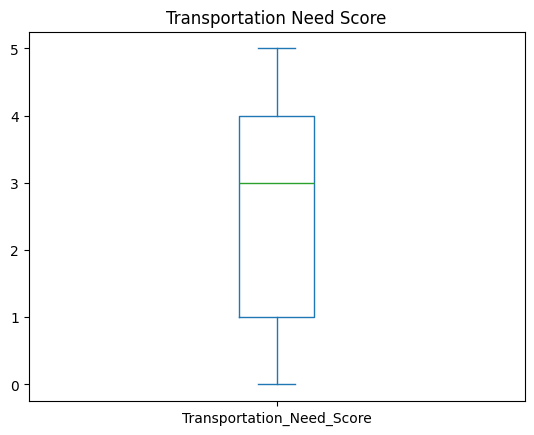

In [46]:

slcm_clean['Transportation_Need_Score'].plot(kind='box')
plt.title('Transportation Need Score')
plt.show()

In [47]:
columns = [
    'Monthly_Housing_Cost',
    'Monthly_LGE_Bill',
    'Monthly_Water_Bill'
]

for column in columns:

    Q1 = slcm_clean[column].quantile(0.25)
    Q3 = slcm_clean[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    median = slcm_clean[column].median()

    slcm_clean.loc[
        (slcm_clean[column] < lower_bound) |
        (slcm_clean[column] > upper_bound),
        column
    ] = median

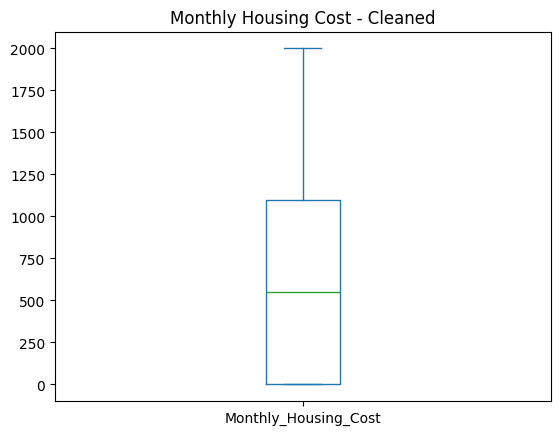

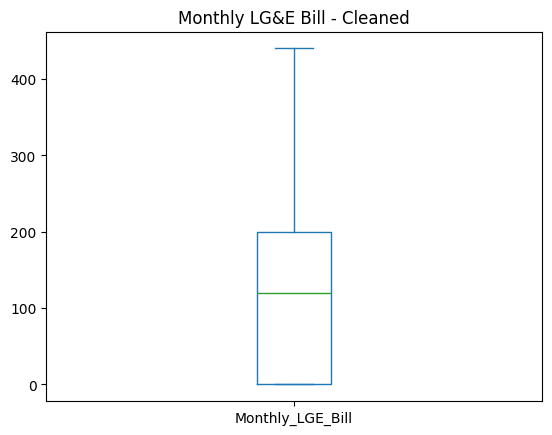

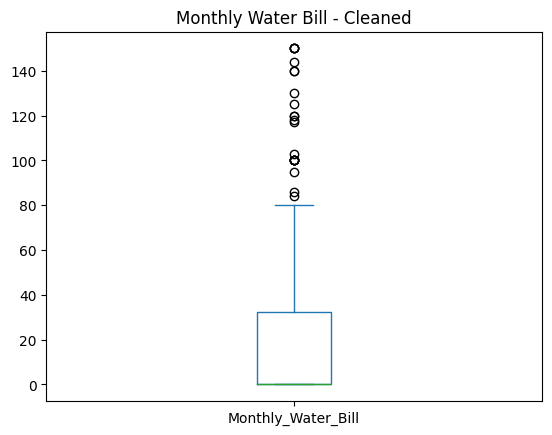

In [48]:
import matplotlib.pyplot as plt
%matplotlib inline

slcm_clean['Monthly_Housing_Cost'].plot(kind='box')
plt.title('Monthly Housing Cost - Cleaned')
plt.show()

slcm_clean['Monthly_LGE_Bill'].plot(kind='box')
plt.title('Monthly LG&E Bill - Cleaned')
plt.show()

slcm_clean['Monthly_Water_Bill'].plot(kind='box')
plt.title('Monthly Water Bill - Cleaned')
plt.show()

I identified outliers in Monthly_Housing_Cost, Monthly_LGE_Bill, and Monthly_Water_Bill using the IQR method. Any value below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR was considered an outlier. I replaced those outlier values with the median of the corresponding variable because the median is less affected by extreme values.

To verify that the cleaning worked, I created new box plots for the three variables after replacing the outliers. The updated plots showed that the extreme values had been removed and replaced with values closer to the center of the distribution.

In [49]:
categorical_columns = [
    'Housing_Status',
    'Utility_Disconnection_Risk',
    'Eviction_Record',
    'Has_Car',
    'Bus_Use',
    'Moves_Last_3_Years'
]
for column in categorical_columns:
    print(column)
    print(slcm_clean[column].unique())
    print()

Housing_Status
['Renter - past due rent' 'Staying with friends or family' 'Homeless'
 'Renter - no rent past due'
 'Staying at extended stay hotel or short-term housing'
 'Own home - mortgage past due']

Utility_Disconnection_Risk
['Yes' 'No' 'Maybe']

Eviction_Record
['No' 'Yes' 'Not sure']

Has_Car
['Yes' 'No']

Bus_Use
['Never' 'Sometimes' 'Rarely' 'Often']

Moves_Last_3_Years
['0' '1' '4' '2' '3' 'More than 5' '5']



In [50]:
# Remove exact duplicate rows
slcm_clean = slcm_clean.drop_duplicates()

# Verify that duplicates are gone
print("Duplicate rows:", slcm_clean.duplicated().sum())
print("Number of rows:", len(slcm_clean))


Duplicate rows: 0
Number of rows: 165


For my second cleaning change, I removed the exact duplicate row from the dataset using drop_duplicates(). The duplicate had identical values across all variables, so I treated it as a repeated record and removed one copy to avoid counting the same information twice in later analysis. After removing the duplicate, I checked the dataset again and confirmed that there were no duplicate rows remaining. The number of records decreased from 166 to 165.

Because the dataset does not include a unique participant ID, it is not possible to know with complete certainty whether the identical rows represent the same person, but I chose to remove the duplicate as a reasonable data-cleaning step.

# Part 3 – Guided Exploration and Visualization

10. What does housing status look like in this dataset?

• Create a frequency table for Housing_Status.

• Create an appropriate visualization.

• Which housing status is most common? What do you notice about the overall distribution?

In [51]:
# Frequency table
slcm_clean['Housing_Status'].value_counts()

,count
Housing_Status,
Renter - no rent past due,68
Renter - past due rent,51
Homeless,18
Staying at extended stay hotel or short-term housing,15
Staying with friends or family,12
Own home - mortgage past due,1


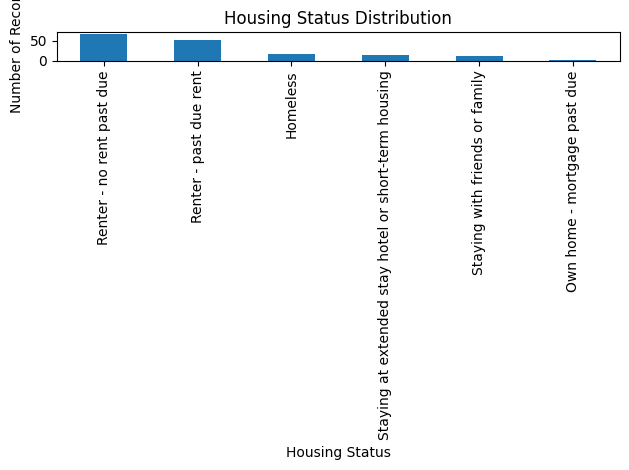

In [52]:
%matplotlib inline

slcm_clean['Housing_Status'].value_counts().plot(kind='bar')

plt.title('Housing Status Distribution')
plt.xlabel('Housing Status')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

The most common housing status is Renter - no rent past due, with 68 records. The second most common category is Renter - past due rent, with 51 records. Most people in the dataset are renters, while fewer people are homeless, staying with friends or family, or staying in short-term housing. Only one person is in the Own home - mortgage past due category, making it the least common housing status.

11. How does monthly housing cost vary across housing situations?

• Compare Monthly_Housing_Cost across Housing_Status.

• Use a suitable summary and/or visualization.

• What pattern do you notice?

• Be careful when interpreting zero housing cost. Explain why

In [53]:
# Summary statistics by housing status
housing_cost_summary = slcm_clean.groupby('Housing_Status')['Monthly_Housing_Cost'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

print(housing_cost_summary)

                                                    count         mean  \
Housing_Status                                                           
Homeless                                               18    50.057778   
Own home - mortgage past due                            1  1376.020000   
Renter - no rent past due                              68   596.082662   
Renter - past due rent                                 51   917.470784   
Staying at extended stay hotel or short-term ho...     15   740.867333   
Staying with friends or family                         12   255.835250   

                                                     median      min      max  
Housing_Status                                                                 
Homeless                                               0.00     0.00   900.00  
Own home - mortgage past due                        1376.02  1376.02  1376.02  
Renter - no rent past due                            366.00     0.00  1800.00  
Renter 

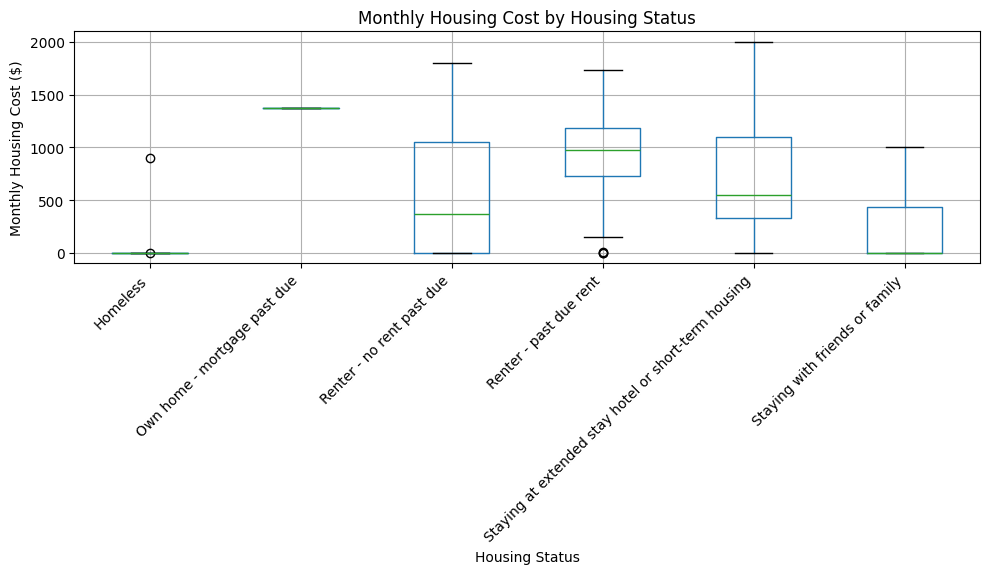

In [54]:
%matplotlib inline

slcm_clean.boxplot(
    column='Monthly_Housing_Cost',
    by='Housing_Status',
    figsize=(10, 6)
)

plt.title('Monthly Housing Cost by Housing Status')
plt.suptitle('')
plt.xlabel('Housing Status')
plt.ylabel('Monthly Housing Cost ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Monthly housing cost varies noticeably across housing situations. Renters with past-due rent generally have higher monthly housing costs than renters with no rent past due. People who are homeless or staying with friends or family tend to have much lower housing costs. However, a housing cost of $0 should not automatically be considered incorrect because someone may be homeless, staying with another person without paying rent, or have their housing costs covered by someone else.

12. Is utility disconnection risk associated with a different LG&E bill pattern?

• Compare Monthly_LGE_Bill for people with different Utility_Disconnection_Risk values.

• Create an appropriate visualization.

• Describe what you observe. Do not claim that one variable causes the other.

In [55]:
# Summary statistics
lge_summary = slcm_clean.groupby(
    'Utility_Disconnection_Risk'
)['Monthly_LGE_Bill'].agg(['count', 'mean', 'median', 'min', 'max'])

print(lge_summary)

                            count        mean  median   min    max
Utility_Disconnection_Risk                                        
Maybe                          10  205.700000   185.0  75.0  400.0
No                            115   95.187227    96.0   0.0  440.0
Yes                            40  173.750500   172.5   0.0  400.0


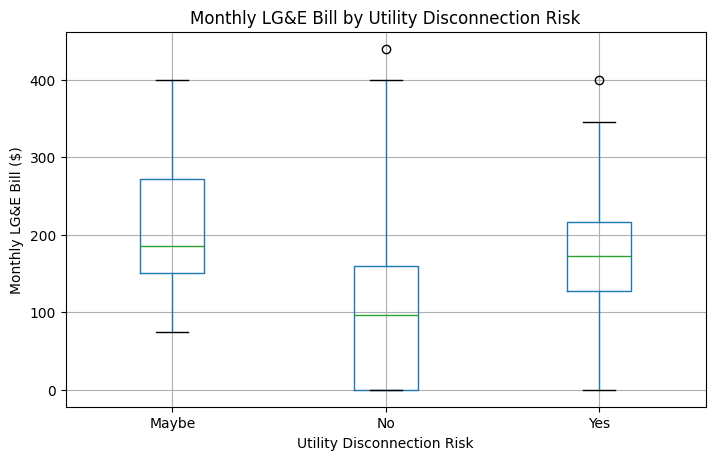

In [56]:
%matplotlib inline

slcm_clean.boxplot(
    column='Monthly_LGE_Bill',
    by='Utility_Disconnection_Risk',
    figsize=(8, 5)
)

plt.title('Monthly LG&E Bill by Utility Disconnection Risk')
plt.suptitle('')
plt.xlabel('Utility Disconnection Risk')
plt.ylabel('Monthly LG&E Bill ($)')
plt.show()

The LG&E bill pattern appears to differ across the utility disconnection risk categories. People who are at risk of utility disconnection tend to have higher monthly LG&E bills than people who are not at risk. The box plot and summary statistics suggest an association between higher LG&E bills and disconnection risk. However, this does not mean that a higher LG&E bill causes the disconnection risk, since other factors may also be involved.

13. What does transportation need look like for people with and without a car?

• Compare Transportation_Need_Score by Has_Car.

• Use summary statistics and a visualization.

• Does car ownership appear related to transportation need in this dataset? Explain using evidence.

In [57]:
transport_summary = slcm_clean.groupby(
    'Has_Car'
)['Transportation_Need_Score'].agg(
    ['count', 'mean', 'median', 'min', 'max']
)

print(transport_summary)

         count      mean  median  min  max
Has_Car                                   
No          79  3.265823     4.0    0    5
Yes         86  1.697674     1.0    0    5


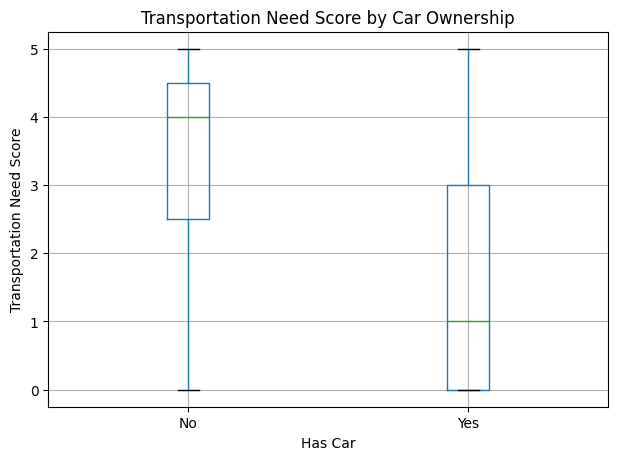

In [58]:
%matplotlib inline

slcm_clean.boxplot(
    column='Transportation_Need_Score',
    by='Has_Car',
    figsize=(7, 5)
)

plt.title('Transportation Need Score by Car Ownership')
plt.suptitle('')
plt.xlabel('Has Car')
plt.ylabel('Transportation Need Score')
plt.show()

People without a car have a higher transportation need score than people with a car. Those without a car have an average score of about 3.27 and a median of 4, while those with a car have an average score of about 1.70 and a median of 1. This suggests that car ownership is associated with lower transportation need in this dataset. However, this only shows a relationship and does not prove that owning a car directly causes lower transportation need.

14. How is bus use distributed?

• Create a frequency table and visualization for Bus_Use.

• What is the most common bus-use category?

• What additional variable would you compare with Bus_Use if you wanted to understand transportation
needs better? Why?


In [59]:
slcm_clean['Bus_Use'].value_counts()

,count
Bus_Use,
Never,65
Often,47
Sometimes,35
Rarely,18


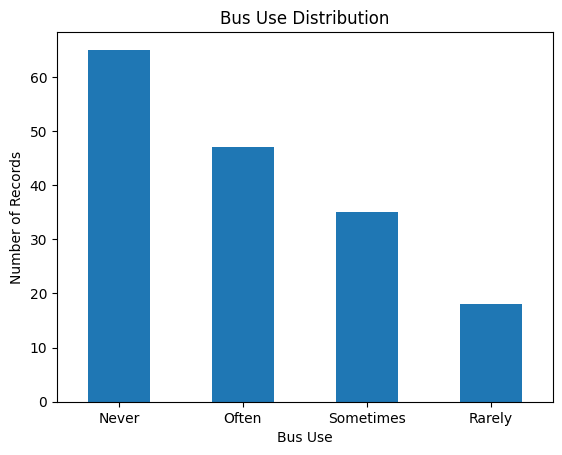

In [60]:
%matplotlib inline

slcm_clean['Bus_Use'].value_counts().plot(kind='bar')

plt.title('Bus Use Distribution')
plt.xlabel('Bus Use')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

The most common bus-use category is Never, with 65 records. This is followed by Often with 47 records, Sometimes with 35 records, and Rarely with 18 records. I would compare Bus_Use with Transportation_Need_Score because this could show whether people who use the bus more frequently also report greater transportation needs.

15. What is your question?

• Write the question clearly.

• Why did you choose this question? What made you curious about it, and why might it be useful to
understand?

• Which variables will you use to investigate it?


My question is: **How do car ownership and bus use relate to transportation need?**

I chose this question because transportation need may depend on both whether a person owns a car and how often they use the bus. I was curious to see whether people without cars who use the bus frequently have greater transportation needs than people who own cars. This could help show how access to both personal and public transportation relates to transportation needs. I will use `Has_Car`, `Bus_Use`, and `Transportation_Need_Score`.


16. What does the data tell you?

• Use appropriate calculations, grouping, and/or visualization to investigate your question.

• Show evidence rather than giving only an opinion.

• Explain what the result suggests in plain language

In [65]:
slcm_clean.groupby(
    ['Has_Car', 'Bus_Use']
)['Transportation_Need_Score'].agg(
    ['count', 'mean', 'median']
)





count      mean  median
Has_Car Bus_Use                           
No      Never         12  3.583333     3.0
        Often         44  3.250000     4.0
        Rarely         6  2.833333     3.0
        Sometimes     17  3.235294     4.0
Yes     Never         53  1.377358     1.0
        Often          3  3.000000     3.0
        Rarely        12  1.583333     0.5
        Sometimes     18  2.500000     2.5

In [67]:
slcm_clean.pivot_table(
    values='Transportation_Need_Score',
    index='Bus_Use',
    columns='Has_Car',
    aggfunc='mean'
)


Has_Car,No,Yes
Bus_Use,,
Never,3.583333,1.377358
Often,3.250000,3.000000
Rarely,2.833333,1.583333
Sometimes,3.235294,2.500000


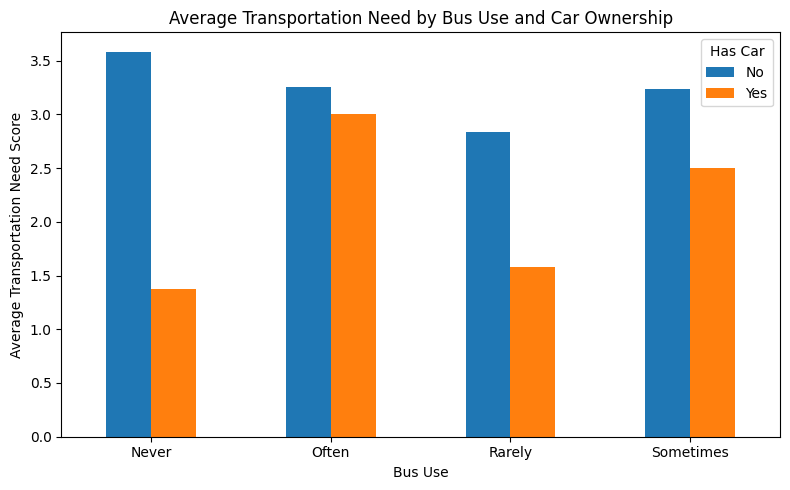

In [68]:
transport_table.plot(kind='bar', figsize=(8, 5))

plt.title('Average Transportation Need by Bus Use and Car Ownership')
plt.xlabel('Bus Use')
plt.ylabel('Average Transportation Need Score')
plt.xticks(rotation=0)
plt.legend(title='Has Car')
plt.tight_layout()
plt.show()

The data shows that people who use the bus more often tend to have higher transportation need scores. People who Often use the bus have the highest average transportation need score at about 3.23, followed by people who use it Sometimes at about 2.86. In comparison, people who Never use the bus have a much lower average score of about 1.78. This suggests that more frequent bus use is associated with greater transportation need in this dataset.Overall, the data suggests that both car ownership and bus use are related to transportation need. People without cars generally appear to have higher transportation need scores, and frequent bus users also tend to report greater transportation needs. Looking at the variables together gives a clearer picture than looking at car ownership or bus use alone because transportation needs may depend on access to multiple forms of transportation. However, these relationships are only associations, so the data cannot prove that car ownership or bus use causes a person's transportation need.
